In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("future.no_silent_downcasting", True)

In [133]:
gender_age = pd.read_csv("gender_age.csv")
# gender_rt = pd.read_csv("gender_rt.csv")

In [48]:
# plt.figure(figsize=(10, 6))
# sns.regplot(
#     data=gender_rt,
#     x="avg_male_words",
#     y="tomatometer_rating",
#     scatter_kws={"alpha": 0.25, "color": "steelblue"},
#     line_kws={"color": "darkblue"}
# )

# plt.title("Rotten Tomatoes Rating vs Average Word Count for Male Characters")
# plt.xlabel("Number of Words")
# plt.ylabel("Tomatometer Rating")
# plt.show()

# plt.figure(figsize=(10, 6))
# sns.regplot(
#     data=gender_rt,
#     x="avg_female_words",
#     y="tomatometer_rating",
#     scatter_kws={"alpha": 0.25, "color": "lightcoral"},
#     line_kws={"color": "darkred"}
# )

# plt.title("Rotten Tomatoes Rating vs Average Word Count for Female Characters")
# plt.xlabel("Number of Words")
# plt.ylabel("Tomatometer Rating")
# plt.show()

# AGE

In [134]:
gender_age["gender"] = gender_age["gender"].astype("category")

# Encode booleans as binary
gender_age["actor_nom"] = gender_age["actor_nom"].astype(int)
gender_age["actor_win"] = gender_age["actor_win"].astype(int)
gender_age["actress_nom"] = gender_age["actress_nom"].astype(int)
gender_age["actress_win"] = gender_age["actress_win"].astype(int)

# Split the dataframe by gender
gender_age_male = gender_age[gender_age["gender"] == "m"]
gender_age_female = gender_age[gender_age["gender"] == "f"]

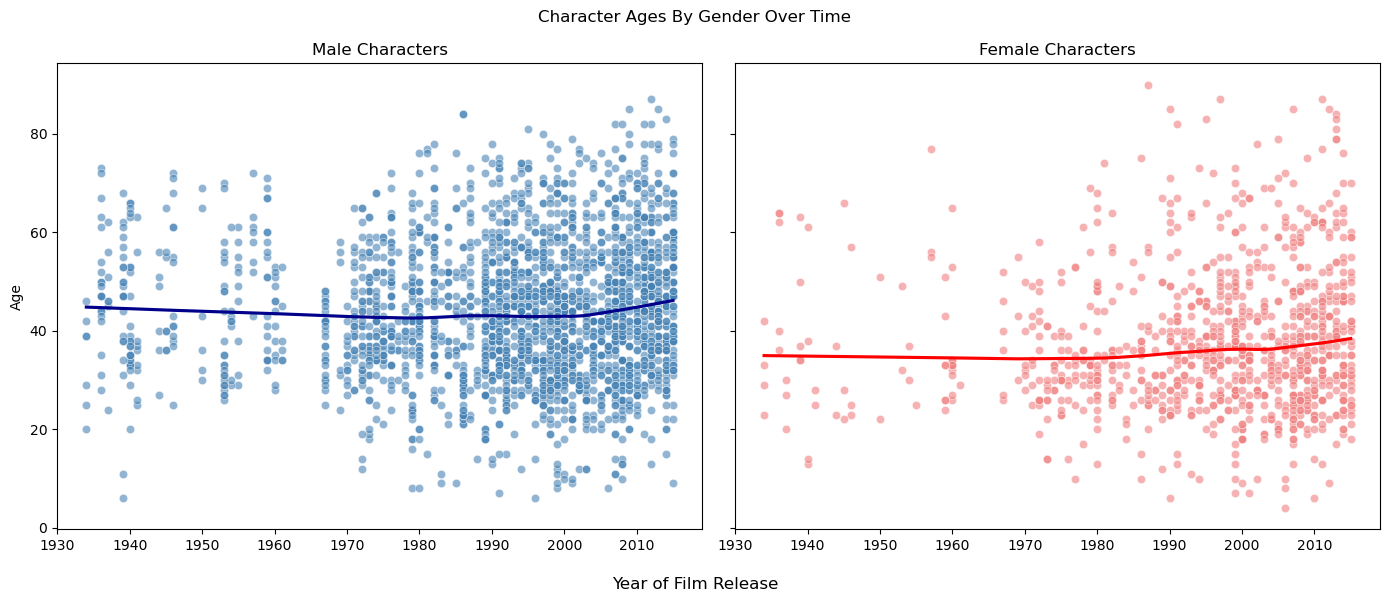

In [ ]:
# sns.lmplot(
#     x="year",
#     y="age",
#     hue="gender",
#     palette={"m": "steelblue", "f": "lightcoral"},
#     data=gender_age,
#     lowess=True,
#     height=5,
#     aspect=1.5
# )
# plt.title("Smoothed Trend of Character Ages by Gender Over Years")
# plt.xlabel("Film Year")
# plt.ylabel("Character Age")
# plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True, sharex=True)

# Male characters
sns.scatterplot(
    x="year", y="age", data=gender_age_male,
    alpha=0.6, ax=axes[0], color="steelblue"
)
sns.regplot(
    x="year", y="age", data=gender_age_male,
    scatter=False, lowess=True, ax=axes[0], color="darkblue"
)
axes[0].set_title("Male Characters")
axes[0].set_xlabel("")
axes[0].set_ylabel("Age")

# Female characters
sns.scatterplot(
    x="year", y="age", data=gender_age_female,
    alpha=0.6, ax=axes[1], color="lightcoral"
)
sns.regplot(
    x="year", y="age", data=gender_age_female,
    scatter=False, lowess=True, ax=axes[1], color="red"
)
axes[1].set_title("Female Characters")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

fig.supxlabel("Year of Film Release")
plt.suptitle("Character Ages By Gender Over Time")
plt.tight_layout()
plt.show()

Optimization terminated successfully.
         Current function value: 0.543500
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:              actor_nom   No. Observations:                 2416
Model:                          Logit   Df Residuals:                     2414
Method:                           MLE   Df Model:                            1
Date:                Mon, 24 Nov 2025   Pseudo R-squ.:               0.0007284
Time:                        18:11:52   Log-Likelihood:                -1313.1
converged:                       True   LL-Null:                       -1314.1
Covariance Type:            nonrobust   LLR p-value:                    0.1665
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9749      0.160      6.097      0.000       0.662       1.288
age            0.0048      0.

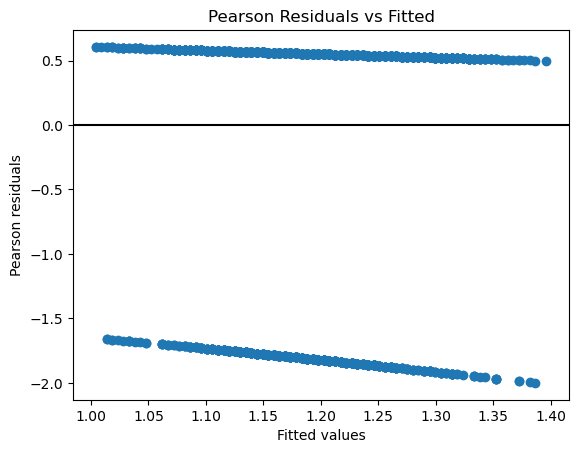

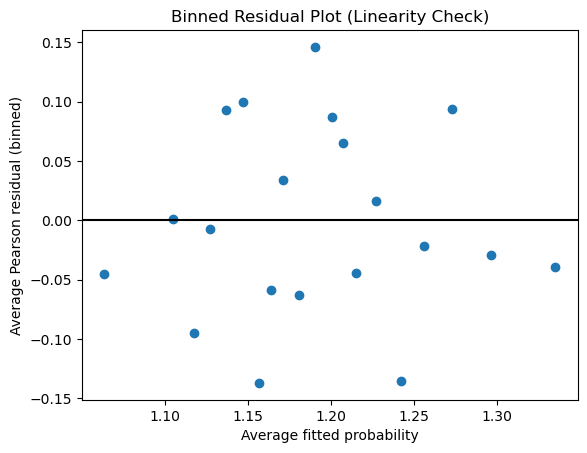

In [131]:
age_lg1 = smf.logit(formula="actor_nom ~ age", data=gender_age_male).fit()
print(age_lg1.summary())

# age_lg2 = smf.logit(formula="actor_win ~ age", data=gender_age_male).fit()
# print(age_lg2.summary())

# resid
plt.scatter(age_lg1.fittedvalues, age_lg1.resid_pearson)
plt.axhline(0, color='black')
plt.xlabel("Fitted values")
plt.ylabel("Pearson residuals")
plt.title("Pearson Residuals vs Fitted")
plt.show()

# binned Pearson resid
bins = pd.qcut(age_lg1.fittedvalues, q=20, duplicates="drop")
binned = age_lg1.resid_pearson.groupby(bins, observed=False).mean()
centers = age_lg1.fittedvalues.groupby(bins, observed=False).mean()
plt.scatter(centers, binned)
plt.axhline(0, color='black')
plt.xlabel("Average fitted probability")
plt.ylabel("Average Pearson residual (binned)")
plt.title("Binned Residual Plot (Linearity Check)")
plt.show()

Optimization terminated successfully.
         Current function value: 0.621241
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            actress_nom   No. Observations:                  966
Model:                          Logit   Df Residuals:                      964
Method:                           MLE   Df Model:                            1
Date:                Mon, 24 Nov 2025   Pseudo R-squ.:                0.007590
Time:                        18:15:07   Log-Likelihood:                -600.12
converged:                       True   LL-Null:                       -604.71
Covariance Type:            nonrobust   LLR p-value:                  0.002447
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2045      0.196      1.042      0.297      -0.180       0.589
age            0.0149      0.

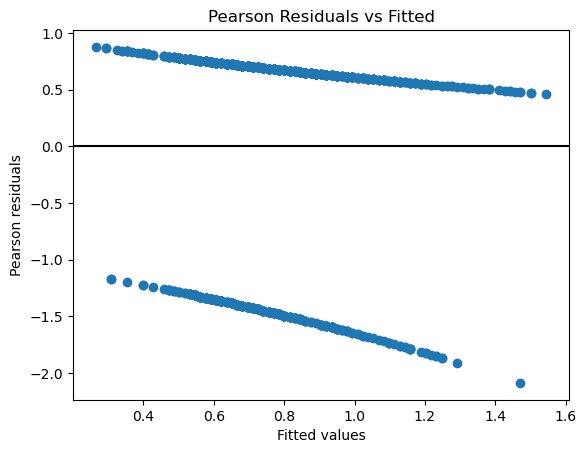

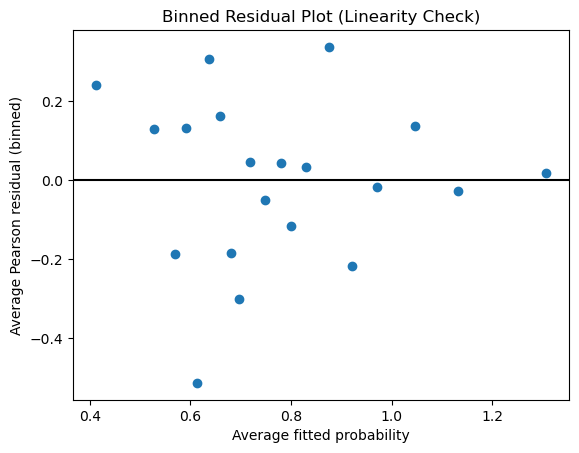

In [132]:
age_lg3 = smf.logit(formula="actress_nom ~ age", data=gender_age_female).fit()
print(age_lg3.summary())

# age_lg4 = smf.logit(formula="actress_win ~ age", data=gender_age_female).fit()
# print(age_lg4.summary())

# resid
plt.scatter(age_lg3.fittedvalues, age_lg3.resid_pearson)
plt.axhline(0, color='black')
plt.xlabel("Fitted values")
plt.ylabel("Pearson residuals")
plt.title("Pearson Residuals vs Fitted")
plt.show()

# binned Pearson resid
bins = pd.qcut(age_lg3.fittedvalues, q=20, duplicates="drop")
binned = age_lg3.resid_pearson.groupby(bins, observed=False).mean()
centers = age_lg3.fittedvalues.groupby(bins, observed=False).mean()
plt.scatter(centers, binned)
plt.axhline(0, color='black')
plt.xlabel("Average fitted probability")
plt.ylabel("Average Pearson residual (binned)")
plt.title("Binned Residual Plot (Linearity Check)")
plt.show()

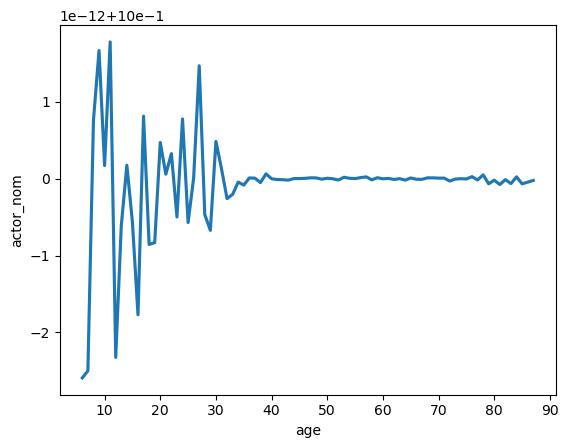

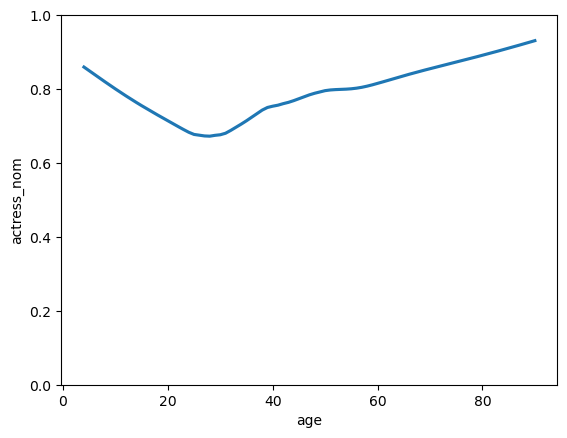

In [110]:
sns.regplot(x='age', y='actor_nom', data=gender_age_male, scatter=False, lowess=True)
plt.show()

sns.regplot(x='age', y='actress_nom', data=gender_age_female, scatter=False, lowess=True)
plt.ylim([0, 1])
plt.show()

In [ ]:
# gender_age_male["age2"] = gender_age_male["age"] ** 2

# age_lg7 = smf.logit(formula="actor_win ~ age2", data=gender_age_male).fit()
# print(age_lg7.summary())

# gender_age_female["age2"] = gender_age_female["age"] ** 2

# age_lg5 = smf.logit(formula="actress_nom ~ age2", data=gender_age_female).fit()
# print(age_lg5.summary())

# model_quad = smf.logit(
#     "actress_nom ~ age + age2",
#     data=gender_age_female
# ).fit()
# print(model_quad.summary())

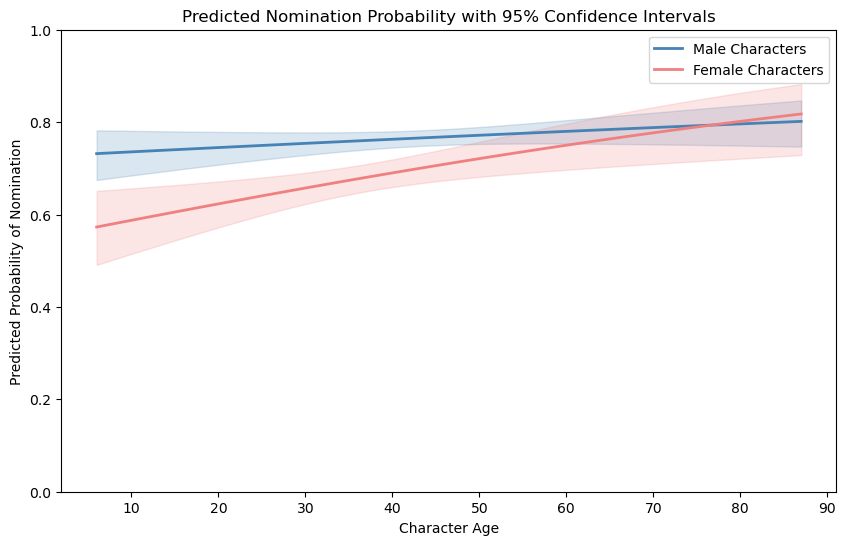

In [ ]:
age_grid = np.linspace(gender_age_male['age'].min(), gender_age_male['age'].max(), 100)

# Actor model
df_actor = pd.DataFrame({'age': age_grid})
pred_actor = age_lg1.get_prediction(df_actor).summary_frame(alpha=0.05)
df_actor['pred_prob'] = pred_actor['predicted']
df_actor['ci_lower'] = pred_actor['ci_lower']
df_actor['ci_upper'] = pred_actor['ci_upper']

# Actress model
df_actress = pd.DataFrame({'age': age_grid})
pred_actress = age_lg3.get_prediction(df_actress).summary_frame(alpha=0.05)
df_actress['pred_prob'] = pred_actress['predicted']
df_actress['ci_lower'] = pred_actress['ci_lower']
df_actress['ci_upper'] = pred_actress['ci_upper']

# plt.figure(figsize=(8,6))
# plt.plot(df_actor['age'], df_actor['pred_prob'], label='Male Characters', color='steelblue')
# plt.plot(df_actress['age'], df_actress['pred_prob'], label='Female Characters', color='lightcoral')
# plt.xlabel("Character Age")
# plt.ylabel("Predicted Probability of Nomination")
# plt.ylim([0, 1])
# plt.title("Predicted Nomination Probability vs Age")
# plt.legend()
# plt.show()

plt.figure(figsize=(10,6))
plt.plot(df_actor['age'], df_actor['pred_prob'], color='steelblue', label='Male Characters', linewidth=2)
plt.fill_between(df_actor['age'], df_actor['ci_lower'], df_actor['ci_upper'], color='steelblue', alpha=0.2)
plt.plot(df_actress['age'], df_actress['pred_prob'], color='lightcoral', label='Female Characters', linewidth=2)
plt.fill_between(df_actress['age'], df_actress['ci_lower'], df_actress['ci_upper'], color='lightcoral', alpha=0.2)

plt.xlabel("Character Age")
plt.ylabel("Predicted Probability of Nomination")
plt.ylim([0, 1])
plt.title("Predicted Nomination Probability with 95% Confidence Intervals")
plt.legend()
plt.show()


In [146]:
max_male_per_group = gender_age_male.groupby('title')['words'].transform('max')
main_male = gender_age_male[gender_age_male['words'] == max_male_per_group]

print(main_male.head())

max_female_per_group = gender_age_female.groupby('title')['words'].transform('max')
main_female = gender_age_female[gender_age_female['words'] == max_female_per_group]

print(main_female.head())

          character  words gender   age                          title  year  \
4    robert kincaid   1908      m  65.0  the bridges of madison county  1995   
18     muhammad ali   4042      m  33.0                            ali  2001   
35  wolfgang amadeu   3826      m  31.0                        amadeus  1984   
38      frank lucas   2480      m  53.0              american gangster  2007   
63            terry   1604      m  20.0              american graffiti  1973   

   dominant_gender  actor_nom  actress_nom  actor_win  actress_win  \
4                m          0            1          0            0   
18               m          1            0          0            0   
35               m          1            0          1            0   
38               m          0            1          0            0   
63               m          0            1          0            0   

    actor_noms  actress_noms  actor_wins  actress_wins df_type  
4            0             1     

Optimization terminated successfully.
         Current function value: 0.604512
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:              actor_nom   No. Observations:                  314
Model:                          Logit   Df Residuals:                      312
Method:                           MLE   Df Model:                            1
Date:                Mon, 24 Nov 2025   Pseudo R-squ.:               0.0004937
Time:                        20:12:35   Log-Likelihood:                -189.82
converged:                       True   LL-Null:                       -189.91
Covariance Type:            nonrobust   LLR p-value:                    0.6650
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6928      0.451      1.535      0.125      -0.192       1.578
age            0.0045      0.

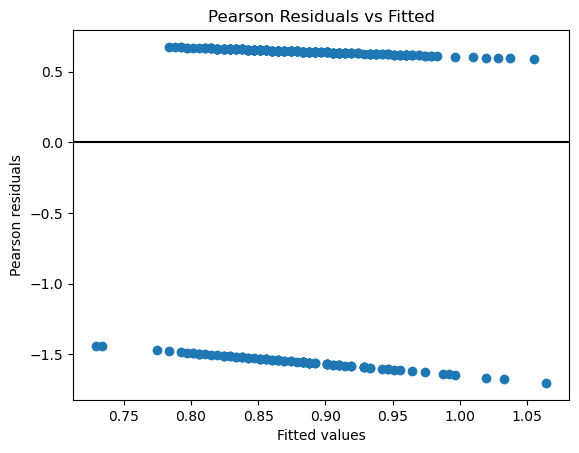

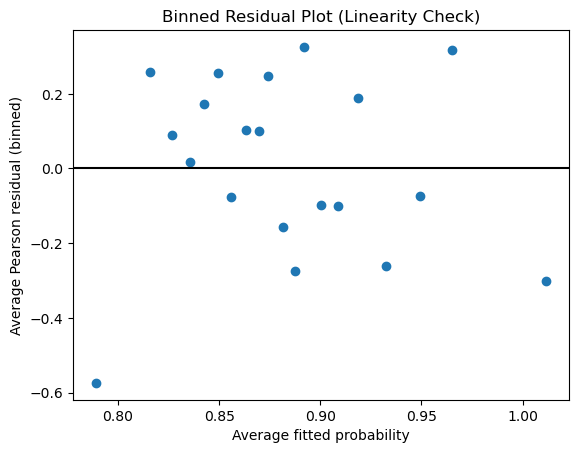

In [147]:
mm_lg1 = smf.logit(formula="actor_nom ~ age", data=main_male).fit()
print(mm_lg1.summary())

# resid
plt.scatter(mm_lg1.fittedvalues, mm_lg1.resid_pearson)
plt.axhline(0, color='black')
plt.xlabel("Fitted values")
plt.ylabel("Pearson residuals")
plt.title("Pearson Residuals vs Fitted")
plt.show()

# binned Pearson resid
bins = pd.qcut(mm_lg1.fittedvalues, q=20, duplicates="drop")
binned = mm_lg1.resid_pearson.groupby(bins, observed=False).mean()
centers = mm_lg1.fittedvalues.groupby(bins, observed=False).mean()
plt.scatter(centers, binned)
plt.axhline(0, color='black')
plt.xlabel("Average fitted probability")
plt.ylabel("Average Pearson residual (binned)")
plt.title("Binned Residual Plot (Linearity Check)")
plt.show()

Optimization terminated successfully.
         Current function value: 0.666086
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            actress_nom   No. Observations:                  302
Model:                          Logit   Df Residuals:                      300
Method:                           MLE   Df Model:                            1
Date:                Mon, 24 Nov 2025   Pseudo R-squ.:                 0.01068
Time:                        20:13:23   Log-Likelihood:                -201.16
converged:                       True   LL-Null:                       -203.33
Covariance Type:            nonrobust   LLR p-value:                   0.03713
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3173      0.370     -0.857      0.391      -1.043       0.408
age            0.0202      0.

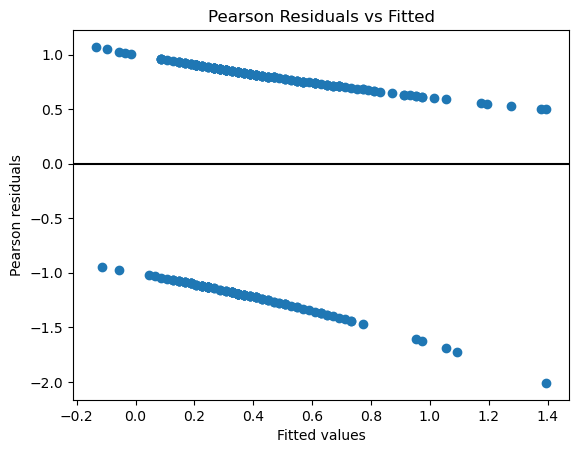

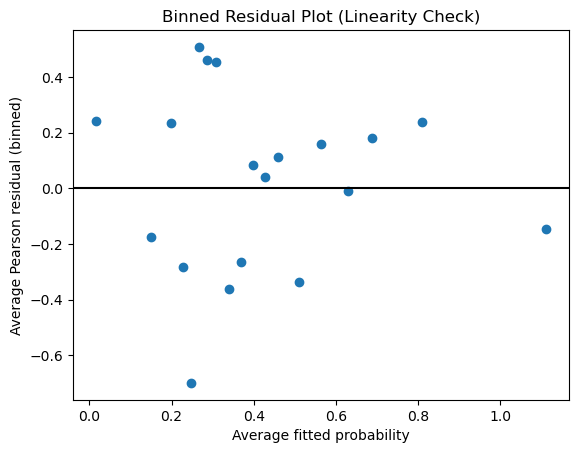

In [148]:
mf_lg1 = smf.logit(formula="actress_nom ~ age", data=main_female).fit()
print(mf_lg1.summary())

# resid
plt.scatter(mf_lg1.fittedvalues, mf_lg1.resid_pearson)
plt.axhline(0, color='black')
plt.xlabel("Fitted values")
plt.ylabel("Pearson residuals")
plt.title("Pearson Residuals vs Fitted")
plt.show()

# binned Pearson resid
bins = pd.qcut(mf_lg1.fittedvalues, q=20, duplicates="drop")
binned = mf_lg1.resid_pearson.groupby(bins, observed=False).mean()
centers = mf_lg1.fittedvalues.groupby(bins, observed=False).mean()
plt.scatter(centers, binned)
plt.axhline(0, color='black')
plt.xlabel("Average fitted probability")
plt.ylabel("Average Pearson residual (binned)")
plt.title("Binned Residual Plot (Linearity Check)")
plt.show()

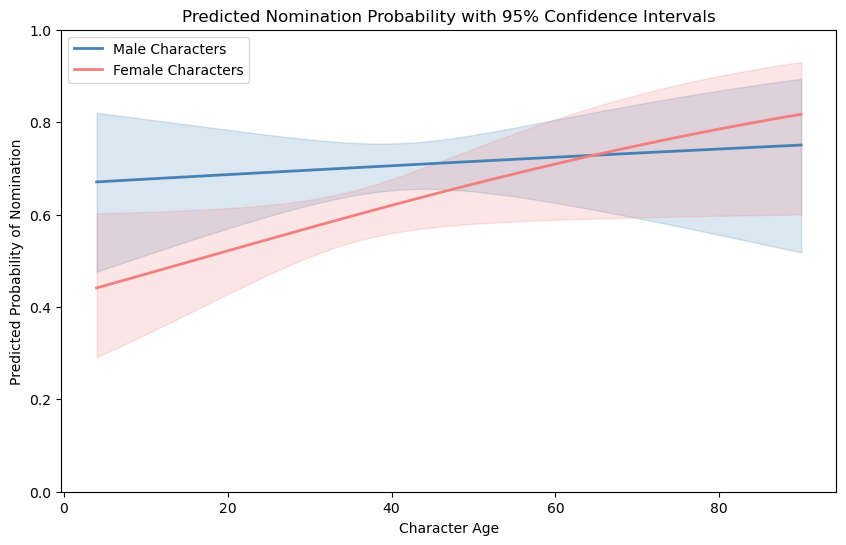

In [149]:
age_grid = np.linspace(gender_age['age'].min(), gender_age['age'].max(), 100)

# Actor model
df_actor = pd.DataFrame({'age': age_grid})
pred_actor = mm_lg1.get_prediction(df_actor).summary_frame(alpha=0.05)
df_actor['pred_prob'] = pred_actor['predicted']
df_actor['ci_lower'] = pred_actor['ci_lower']
df_actor['ci_upper'] = pred_actor['ci_upper']

# Actress model
df_actress = pd.DataFrame({'age': age_grid})
pred_actress = mf_lg1.get_prediction(df_actress).summary_frame(alpha=0.05)
df_actress['pred_prob'] = pred_actress['predicted']
df_actress['ci_lower'] = pred_actress['ci_lower']
df_actress['ci_upper'] = pred_actress['ci_upper']

# plt.figure(figsize=(8,6))
# plt.plot(df_actor['age'], df_actor['pred_prob'], label='Male Characters', color='steelblue')
# plt.plot(df_actress['age'], df_actress['pred_prob'], label='Female Characters', color='lightcoral')
# plt.xlabel("Character Age")
# plt.ylabel("Predicted Probability of Nomination")
# plt.ylim([0, 1])
# plt.title("Predicted Nomination Probability vs Age")
# plt.legend()
# plt.show()

plt.figure(figsize=(10,6))
plt.plot(df_actor['age'], df_actor['pred_prob'], color='steelblue', label='Male Characters', linewidth=2)
plt.fill_between(df_actor['age'], df_actor['ci_lower'], df_actor['ci_upper'], color='steelblue', alpha=0.2)
plt.plot(df_actress['age'], df_actress['pred_prob'], color='lightcoral', label='Female Characters', linewidth=2)
plt.fill_between(df_actress['age'], df_actress['ci_lower'], df_actress['ci_upper'], color='lightcoral', alpha=0.2)

plt.xlabel("Character Age")
plt.ylabel("Predicted Probability of Nomination")
plt.ylim([0, 1])
plt.title("Predicted Nomination Probability with 95% Confidence Intervals")
plt.legend()
plt.show()